**ESTUDIO PREVIO DE LOS DATOS**

In [2]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


In [3]:
dataset = pd.read_csv("C:/Users/veror/OneDrive/MACHINE_LEARN/PROYECTO/Aprendizaje_automatico_proyecto_final/data/rendimiento_estudiantes.csv", sep=";")
dataset.head()

,estado_civil,modo_solicitud,orden_solicitud,curso,asistencia_diurna_vespertina,cualificacion_previa,nota_cualificacion_previa,nacionalidad,cualificacion_madre,cualificacion_padre,...,asignaturas_2sem_convalidadas,asignaturas_2sem_matriculadas,asignaturas_2sem_evaluadas,asignaturas_2sem_aprobadas,nota_media_2sem,asignaturas_2sem_sin_evaluacion,tasa_desempleo,tasa_inflacion,pib,objetivo
0,soltero/a,2a_fase_contingente_general,5,animacion_y_diseno_multimedia,diurna,educacion_secundaria,122.0,portuguesa,educacion_basica_3er_ciclo_o_equivalente,otro_11o_ano,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,abandono
1,soltero/a,estudiante_internacional_licenciatura,1,turismo,diurna,educacion_secundaria,160.0,portuguesa,educacion_secundaria_12o_ano_o_equivalente,educacion_superior_grado,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,graduado
2,soltero/a,1a_fase_contingente_general,5,diseno_de_comunicacion,diurna,educacion_secundaria,122.0,portuguesa,educacion_basica_1er_ciclo_o_equivalente,educacion_basica_1er_ciclo_o_equivalente,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,abandono
3,soltero/a,2a_fase_contingente_general,2,periodismo_y_comunicacion,diurna,educacion_secundaria,122.0,portuguesa,educacion_basica_2o_ciclo_o_equivalente,educacion_basica_1er_ciclo_o_equivalente,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,graduado
4,casado/a,mayor_de_23_anos,1,servicio_social_nocturno,vespertina,educacion_secundaria,100.0,portuguesa,educacion_basica_1er_ciclo_o_equivalente,educacion_basica_2o_ciclo_o_equivalente,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,graduado


In [4]:
dataset = dataset.drop_duplicates()
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   estado_civil                       4424 non-null   object 
 1   modo_solicitud                     4424 non-null   object 
 2   orden_solicitud                    4424 non-null   int64  
 3   curso                              4424 non-null   object 
 4   asistencia_diurna_vespertina       4424 non-null   object 
 5   cualificacion_previa               4424 non-null   object 
 6   nota_cualificacion_previa          4424 non-null   float64
 7   nacionalidad                       4424 non-null   object 
 8   cualificacion_madre                4424 non-null   object 
 9   cualificacion_padre                4424 non-null   object 
 10  ocupacion_madre                    4424 non-null   object 
 11  ocupacion_padre                    4424 non-null   objec

In [5]:
dataset.columns

Index(['estado_civil', 'modo_solicitud', 'orden_solicitud', 'curso',
       'asistencia_diurna_vespertina', 'cualificacion_previa',
       'nota_cualificacion_previa', 'nacionalidad', 'cualificacion_madre',
       'cualificacion_padre', 'ocupacion_madre', 'ocupacion_padre',
       'nota_admision', 'desplazado', 'necesidades_educativas_especiales',
       'deudor', 'matricula_al_dia', 'genero', 'becado',
       'edad_al_matricularse', 'internacional',
       'asignaturas_1sem_convalidadas', 'asignaturas_1sem_matriculadas',
       'asignaturas_1sem_evaluadas', 'asignaturas_1sem_aprobadas',
       'nota_media_1sem', 'asignaturas_1sem_sin_evaluacion',
       'asignaturas_2sem_convalidadas', 'asignaturas_2sem_matriculadas',
       'asignaturas_2sem_evaluadas', 'asignaturas_2sem_aprobadas',
       'nota_media_2sem', 'asignaturas_2sem_sin_evaluacion', 'tasa_desempleo',
       'tasa_inflacion', 'pib', 'objetivo'],
      dtype='object')

In [6]:
demograficas_personales = ['edad_al_matricularse', 'genero', 'nacionalidad', 'desplazado',
                'internacional', 'necesidades_educativas_especiales', 'estado_civil']

dataset[demograficas_personales].describe()

,edad_al_matricularse
count,4424.000000
mean,23.265145
std,7.587816
min,17.000000
25%,19.000000
50%,20.000000
75%,25.000000
max,70.000000


In [7]:
contexto_previo = ['modo_solicitud', 'orden_solicitud', 'curso', 'cualificacion_previa',
                   'nota_cualificacion_previa','cualificacion_madre', 'cualificacion_padre','ocupacion_madre', 'ocupacion_padre',
                    'nota_admision']
dataset[contexto_previo].describe()

,orden_solicitud,nota_cualificacion_previa,nota_admision
count,4424.000000,4424.000000,4424.000000
mean,1.727848,132.613314,126.978119
std,1.313793,13.188332,14.482001
min,0.000000,95.000000,95.000000
25%,1.000000,125.000000,117.900000
50%,1.000000,133.100000,126.100000
75%,2.000000,140.000000,134.800000
max,9.000000,190.000000,190.000000


In [8]:
socioeconomicas = ['becado', 'matricula_al_dia', 'deudor']
dataset[socioeconomicas].describe()

,becado,matricula_al_dia,deudor
count,4424,4424,4424
unique,2,2,2
top,no,si,no
freq,3325,3896,3921


In [9]:
macroeconomicas = ['tasa_desempleo', 'tasa_inflacion', 'pib']
dataset[macroeconomicas].describe()

,tasa_desempleo,tasa_inflacion,pib
count,4424.000000,4424.000000,4424.000000
mean,11.566139,1.228029,0.001969
std,2.663850,1.382711,2.269935
min,7.600000,-0.800000,-4.060000
25%,9.400000,0.300000,-1.700000
50%,11.100000,1.400000,0.320000
75%,13.900000,2.600000,1.790000
max,16.200000,3.700000,3.510000


In [10]:
rend_semestre_1 = ['asignaturas_1sem_convalidadas', 'asignaturas_1sem_matriculadas',
                    'asignaturas_1sem_evaluadas', 'asignaturas_1sem_aprobadas',
                    'nota_media_1sem', 'asignaturas_1sem_sin_evaluacion']
dataset[rend_semestre_1].describe()

,asignaturas_1sem_convalidadas,asignaturas_1sem_matriculadas,asignaturas_1sem_evaluadas,asignaturas_1sem_aprobadas,nota_media_1sem,asignaturas_1sem_sin_evaluacion
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,0.709991,6.270570,8.299051,4.706600,10.640822,0.137658
std,2.360507,2.480178,4.179106,3.094238,4.843663,0.690880
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,5.000000,6.000000,3.000000,11.000000,0.000000
50%,0.000000,6.000000,8.000000,5.000000,12.285714,0.000000
75%,0.000000,7.000000,10.000000,6.000000,13.400000,0.000000
max,20.000000,26.000000,45.000000,26.000000,18.875000,12.000000


In [11]:
rend_semestre_2 = ['asignaturas_2sem_convalidadas', 'asignaturas_2sem_matriculadas',
                    'asignaturas_2sem_evaluadas', 'asignaturas_2sem_aprobadas',
                    'nota_media_2sem', 'asignaturas_2sem_sin_evaluacion']
dataset[rend_semestre_2].describe()

,asignaturas_2sem_convalidadas,asignaturas_2sem_matriculadas,asignaturas_2sem_evaluadas,asignaturas_2sem_aprobadas,nota_media_2sem,asignaturas_2sem_sin_evaluacion
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316
std,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000
50%,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000
75%,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000
max,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000


In [12]:
# Eliminación de valores nulos
print(dataset.isnull().sum())
print("No hay valores nulos")

estado_civil                         0
modo_solicitud                       0
orden_solicitud                      0
curso                                0
asistencia_diurna_vespertina         0
cualificacion_previa                 0
nota_cualificacion_previa            0
nacionalidad                         0
cualificacion_madre                  0
cualificacion_padre                  0
ocupacion_madre                      0
ocupacion_padre                      0
nota_admision                        0
desplazado                           0
necesidades_educativas_especiales    0
deudor                               0
matricula_al_dia                     0
genero                               0
becado                               0
edad_al_matricularse                 0
internacional                        0
asignaturas_1sem_convalidadas        0
asignaturas_1sem_matriculadas        0
asignaturas_1sem_evaluadas           0
asignaturas_1sem_aprobadas           0
nota_media_1sem          

In [13]:
# Balanceo de las clases
dataset['objetivo'].value_counts()

#hay claro desbalanceo -> class_weights? oversampling?

objetivo
graduado       2209
abandono       1421
matriculado     794
Name: count, dtype: int64

**TAREA 1: Clasificación** 

Construimos un modelo de clasificación supervisada para predecir la variable objetivo del dataset: predecir si la situación final del estudiante será Abandono, Matriculado o Graduado.

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

In [15]:
# Separar variables predictoras y variable objetivo
X = dataset.drop('objetivo', axis=1)
y = dataset['objetivo']

In [16]:
# Variables categoricas ->one-hot encoding
categoricas = X.select_dtypes('object').columns
categoricas = categoricas.tolist() #las convertimos en lista 

# Variables numéricas
numericas = X.select_dtypes(['int64', 'float64']).columns 
numericas = numericas.tolist()

print("Categorias: ", categoricas)
print("Numéricas: ", numericas)


Categorias:  ['estado_civil', 'modo_solicitud', 'curso', 'asistencia_diurna_vespertina', 'cualificacion_previa', 'nacionalidad', 'cualificacion_madre', 'cualificacion_padre', 'ocupacion_madre', 'ocupacion_padre', 'desplazado', 'necesidades_educativas_especiales', 'deudor', 'matricula_al_dia', 'genero', 'becado', 'internacional']
Numéricas:  ['orden_solicitud', 'nota_cualificacion_previa', 'nota_admision', 'edad_al_matricularse', 'asignaturas_1sem_convalidadas', 'asignaturas_1sem_matriculadas', 'asignaturas_1sem_evaluadas', 'asignaturas_1sem_aprobadas', 'nota_media_1sem', 'asignaturas_1sem_sin_evaluacion', 'asignaturas_2sem_convalidadas', 'asignaturas_2sem_matriculadas', 'asignaturas_2sem_evaluadas', 'asignaturas_2sem_aprobadas', 'nota_media_2sem', 'asignaturas_2sem_sin_evaluacion', 'tasa_desempleo', 'tasa_inflacion', 'pib']


In [17]:
# División del conjunto de datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [18]:
# One-hot encode categorical variables
encode = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_encoded = encode.fit_transform(X_train[categoricas])                              # Watch out for this!
X_test_encoded = encode.transform(X_test[categoricas]) 
print(X_train_encoded.shape)
# escalar numericas
scale = StandardScaler()
X_train_num = scale.fit_transform(X_train[numericas])
X_test_num = scale.transform(X_test[numericas])
print(X_train_num.shape)


(3539, 225)
(3539, 19)


In [19]:
#junto numericas + categoricas
X_train_final = np.concatenate([X_train_num, X_train_encoded], axis=1)
X_test_final = np.concatenate([X_test_num, X_test_encoded], axis=1)

1.REGRESIÓN LOGÍSTICA

In [20]:
# Regresión Logística
LogReg = LogisticRegression(max_iter=1000, class_weight='balanced', multi_class='multinomial')
LogReg.fit(X_train_final, y_train)
preds_LogReg = LogReg.predict(X_test_final)

print(classification_report(y_test, preds_LogReg))

print("Matriz de confusion Regresión Logística: ")
print(confusion_matrix(y_test, preds_LogReg))

c:\Users\veror\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


              precision    recall  f1-score   support

    abandono       0.80      0.72      0.76       284
    graduado       0.86      0.82      0.84       442
 matriculado       0.43      0.56      0.48       159

    accuracy                           0.74       885
   macro avg       0.70      0.70      0.69       885
weighted avg       0.76      0.74      0.75       885

Matriz de confusion Regresión Logística: 
[[204  24  56]
 [ 15 363  64]
 [ 35  35  89]]


2. K NEAREST NODES

Vamos a buscar el número de vecinos óptimo para nuestros datos mediante validación cruzada.
Recordamos que:
- k pequeño: modelo más sensible al ruido -> overfitting
- k grande: modelo más estable -> underfitting 

In [21]:
# cross validation
from sklearn.model_selection import cross_val_score

valores_k = range(1,31)
medias = {}

for k in valores_k:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_final, y_train, scoring='f1_macro')
    medias[k] = scores.mean()

# mejor número de vecinos
mejor_k = max(medias, key=medias.get)   #recorre las claves del dic y elige la clave cuya media es mayor
print("Mejor k: ", mejor_k)

Mejor k:  8


In [22]:
# KNN
k = mejor_k
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train_final, y_train)
preds_knn = knn.predict(X_test_final)

print(classification_report(y_test, preds_knn))

print("Matriz de confusion KNN:")
print(confusion_matrix(y_test, preds_knn))

              precision    recall  f1-score   support

    abandono       0.79      0.65      0.71       284
    graduado       0.71      0.94      0.81       442
 matriculado       0.40      0.17      0.24       159

    accuracy                           0.71       885
   macro avg       0.63      0.59      0.59       885
weighted avg       0.68      0.71      0.68       885

Matriz de confusion KNN:
[[185  71  28]
 [ 16 414  12]
 [ 34  98  27]]


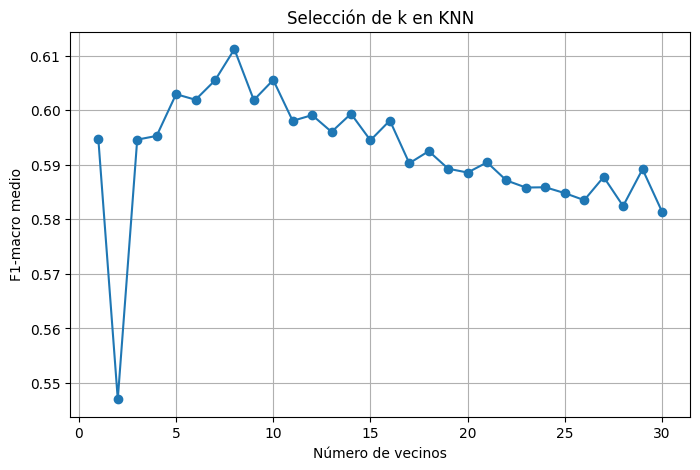

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(valores_k, list(medias.values()), marker='o')
plt.xlabel("Número de vecinos")
plt.ylabel("F1-macro medio")
plt.title("Selección de k en KNN")
plt.grid()
plt.show()

3. RANDOM FOREST

In [24]:
valores_estimadores = [10, 25, 50, 100, 150, 200, 300]
medias_rf = {}

for n in valores_estimadores:
    rf = RandomForestClassifier(n_estimators=n,random_state=42,class_weight='balanced')
    scores = cross_val_score(rf, X_train_final, y_train, scoring='f1_macro')
    medias_rf[n] = scores.mean()

# Mejor número de árboles
mejor_n = max(medias_rf, key=medias_rf.get)
print("Mejor n_estimators: ", mejor_n)


Mejor n_estimators:  100


In [25]:
# Random Forest
rf = RandomForestClassifier(n_estimators=mejor_n, random_state=42)
rf.fit(X_train_final, y_train)
preds_rf = rf.predict(X_test_final)
print(classification_report(y_test, preds_rf))

print("Matriz de confusion Random Forest:")
print(confusion_matrix(y_test, preds_rf))

              precision    recall  f1-score   support

    abandono       0.80      0.75      0.78       284
    graduado       0.78      0.96      0.86       442
 matriculado       0.58      0.28      0.38       159

    accuracy                           0.77       885
   macro avg       0.72      0.66      0.67       885
weighted avg       0.75      0.77      0.75       885

Matriz de confusion Random Forest:
[[214  49  21]
 [  8 423  11]
 [ 44  70  45]]


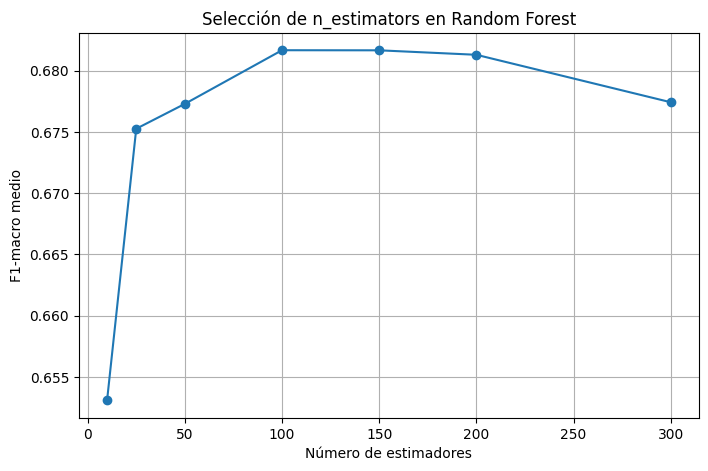

In [26]:
plt.figure(figsize=(8,5))
plt.plot(valores_estimadores, list(medias_rf.values()), marker='o')
plt.xlabel("Número de estimadores")
plt.ylabel("F1-macro medio")
plt.title("Selección de n_estimators en Random Forest")
plt.grid()
plt.show()

IMPORTANCIA DE LAS VARIABLES

In [27]:
features = categoricas + numericas
importance_df = pd.DataFrame({'Feature': features, 'Importance': rf.feature_importances_}).sort_values(by='Importance')

plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.title('Importancia de variables en Bagging')
plt.show()

ValueError: All arrays must be of the same length

COMPARAR RESULTADOS

In [28]:
resultados_modelos = {'Modelo': accuracy_score()

plt.figure(figsize=(8,5))
plt.bar(resultados_modelos["Modelo"], resultados_modelos["F1_macro"])
plt.ylabel("F1-macro")
plt.title("Comparación de modelos")
plt.ylim(0, 1)
plt.show()

SyntaxError: '{' was never closed (3132316078.py, line 1)